# Distingushing the MW and LMC halo particles in phase-space
### Hayden Foote, Himansh Rathore, Gurtina Besla

This notebook uses the idealized lmcsmcmw09 MEGHA simulation by Himansh Rathore to investigate the feasiblity of kinemtically distinguishing LMC halo stars from SMC debris from MW halo stars.

We use the present-day snapshot of the simulation, stored on the University of Arizona's HPC facilities. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from snapanalysis.snap import snapshot # snapanalysis is available from https://github.com/hfoote/snapAnalysis
from snapanalysis import utils
from astropy import units as u
import healpy as hp
from copy import deepcopy

In [2]:
simdir = '/xdisk/gbesla/group/lmcsmcmw09/' # snapshots stored here
comdir = '/xdisk/gbesla/group/lmcsmcmw09/com/' # centers 
rotdir = '/xdisk/gbesla/group/lmcsmcmw09/angular_momentum/' # rotation matrices
min_lmc_id = 1
max_lmc_id = 11600001
min_smc_id = 11600002
max_smc_id = 13144002
min_mw_id = 13144003
max_mw_id = 44144003

# present-day snapshot
pres_idx = 401

In [3]:
# precomputed COMs
lmc_c = np.load(comdir+"LMC_com_pos.npy")[:,pres_idx]*u.kpc
lmc_v = np.load(comdir+"LMC_com_vel.npy")[:,pres_idx]*u.km/u.s
smc_c = np.load(comdir+"SMC_com_pos.npy")[:,pres_idx]*u.kpc
smc_v = np.load(comdir+"SMC_com_vel.npy")[:,pres_idx]*u.km/u.s
MW_c = np.load(comdir+"MW_com_pos.npy")[:,pres_idx]*u.kpc
MW_v = np.load(comdir+"MW_com_vel.npy")[:,pres_idx]*u.km/u.s

# Precomputed rotation to LMC disk plane from the simulation box frame
rot = np.load(rotdir+"LMC_align_matrix.npy")[:,:,pres_idx]

## Particle Selection

We select particles that are within 15 kpc of the center of the LMC. For the MW and LMC, we will use the DM halo particles as a rough proxy for the stellar halo. For the SMC, we want to very roughly pick out the debris, so we use star particles more than 5 kpc from the SMC center.

In [4]:
# mask to select particles from both galaxies within 30 kpc of the LMC center
dm = snapshot(simdir+f"snap_{pres_idx}.hdf5", 1)
dm.read_all()
dm.apply_center(lmc_c, lmc_v)
r = np.sqrt(np.sum(dm.data_fields["Coordinates"]**2, axis=1))
r_max = 15.
mask = r.value < r_max

In [5]:
mw_dm = snapshot(simdir+f"snap_{pres_idx}.hdf5", 1)
mw_dm.read_all()
mw_dm.load_particle_data(["Potential"])
mw_dm.apply_center(MW_c, MW_v)
mw_dm.select_particles(mask)
mw_dm.select_particles((min_mw_id, max_mw_id))

In [6]:
lmc_dm = snapshot(simdir+f"snap_{pres_idx}.hdf5", 1)
lmc_dm.read_all()
lmc_dm.load_particle_data(["Potential"])
lmc_dm.apply_center(MW_c, MW_v)
lmc_dm.select_particles(mask)
lmc_dm.select_particles((min_lmc_id, max_lmc_id))

In [7]:
stars = snapshot(simdir+f"snap_{pres_idx}.hdf5", 2)
stars.read_all()
stars.apply_center(lmc_c, lmc_v)
r = np.sqrt(np.sum(stars.data_fields["Coordinates"]**2, axis=1))
r_max = 15.
mask_stars_lmc = r.value < r_max

stars = snapshot(simdir+f"snap_{pres_idx}.hdf5", 2)
stars.read_all()
stars.apply_center(smc_c, smc_v)
r = np.sqrt(np.sum(stars.data_fields["Coordinates"]**2, axis=1))
r_min = 5.
mask_stars_smc = r.value > r_min

smc_stars = snapshot(simdir+f"snap_{pres_idx}.hdf5", 2)
smc_stars.read_all()
smc_stars.load_particle_data(["Potential"])
smc_stars.apply_center(MW_c, MW_v)
smc_stars.select_particles(mask_stars_lmc & mask_stars_smc)
smc_stars.select_particles((min_smc_id, max_smc_id))

## Phase-space plots
We plot the distribution of the selected particles in various projections of phase-space: 
- Energy-Angular momentum (all three AM components)
- vy-vz, as the LMC's orbit is in the Galactocentric y=z plane, its velocity is most distinct in this projection. 

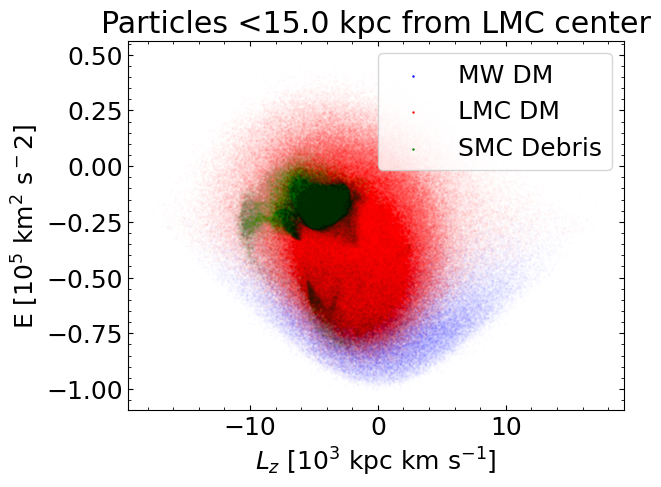

In [8]:
# Energy-angular momentum plot in z-direction
E_mw = np.sum(mw_dm.data_fields['Velocities']**2, axis=1)/2. + mw_dm.data_fields['Potential']
E_lmc = np.sum(lmc_dm.data_fields['Velocities']**2, axis=1)/2. + lmc_dm.data_fields['Potential']
E_smc = np.sum(smc_stars.data_fields['Velocities']**2, axis=1)/2. + smc_stars.data_fields['Potential']

L_mw = np.cross(mw_dm.data_fields['Coordinates'], mw_dm.data_fields['Velocities'])
L_lmc = np.cross(lmc_dm.data_fields['Coordinates'], lmc_dm.data_fields['Velocities'])
L_smc = np.cross(smc_stars.data_fields['Coordinates'], smc_stars.data_fields['Velocities'])

fig, ax = plt.subplots()
ax.scatter(L_mw[:,2]/1e3, E_mw/1e5, c='b', alpha=0.01, s=0.5, label='MW DM')
ax.scatter(L_lmc[:,2]/1e3, E_lmc/1e5, c='r', alpha=0.01, s=0.5, label='LMC DM')
ax.scatter(L_smc[:,2]/1e3, E_smc/1e5, c='g', alpha=0.01, s=0.5, label='SMC Debris')
ax.set(xlabel='$L_z$ [$10^3$ kpc km s$^{-1}$]', ylabel='E [$10^5$ km$^2$ s$^-2$]', title=f"Particles <{r_max} kpc from LMC center")
leg = ax.legend(loc='upper right')
for lh in leg.legend_handles: 
    lh.set_alpha(1.0)

plt.savefig("lmc_mw_smc_ELz.png", bbox_inches='tight')
plt.show()

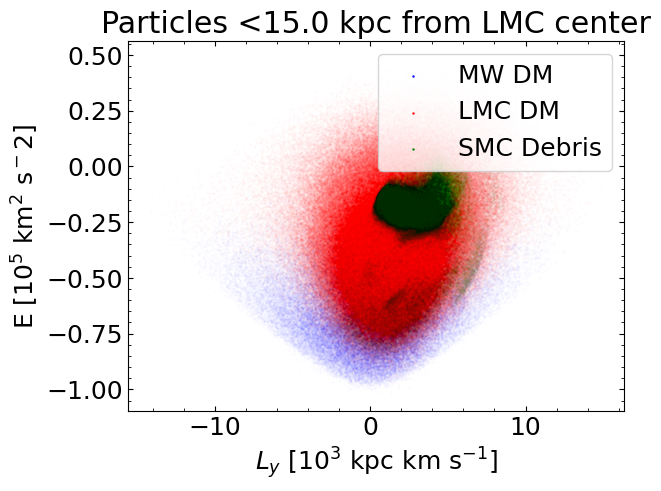

In [9]:
# Energy-angular momentum plot in y-direction
fig, ax = plt.subplots()
ax.scatter(L_mw[:,1]/1e3, E_mw/1e5, c='b', alpha=0.01, s=0.5, label='MW DM')
ax.scatter(L_lmc[:,1]/1e3, E_lmc/1e5, c='r', alpha=0.01, s=0.5, label='LMC DM')
ax.scatter(L_smc[:,1]/1e3, E_smc/1e5, c='g', alpha=0.01, s=0.5, label='SMC Debris')
ax.set(xlabel='$L_y$ [$10^3$ kpc km s$^{-1}$]', ylabel='E [$10^5$ km$^2$ s$^-2$]', title=f"Particles <{r_max} kpc from LMC center")
leg = ax.legend(loc='upper right')
for lh in leg.legend_handles: 
    lh.set_alpha(1.0)

plt.savefig("lmc_mw_smc_ELy.png", bbox_inches='tight')
plt.show()

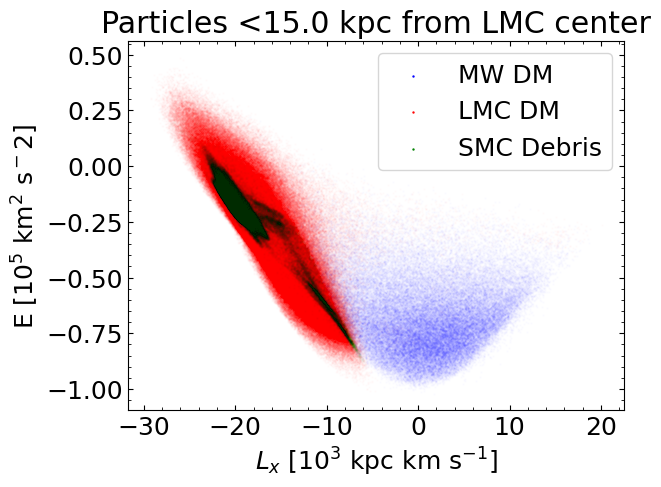

In [10]:
# Energy-angular momentum plot in x-direction
fig, ax = plt.subplots()
ax.scatter(L_mw[:,0]/1e3, E_mw/1e5, c='b', alpha=0.01, s=0.5, label='MW DM')
ax.scatter(L_lmc[:,0]/1e3, E_lmc/1e5, c='r', alpha=0.01, s=0.5, label='LMC DM')
ax.scatter(L_smc[:,0]/1e3, E_smc/1e5, c='g', alpha=0.01, s=0.5, label='SMC Debris')
ax.set(xlabel='$L_x$ [$10^3$ kpc km s$^{-1}$]', ylabel='E [$10^5$ km$^2$ s$^-2$]', title=f"Particles <{r_max} kpc from LMC center")
leg = ax.legend(loc='upper right')
for lh in leg.legend_handles: 
    lh.set_alpha(1.0)

plt.savefig("lmc_mw_smc_ELx.png", bbox_inches='tight')
plt.show()

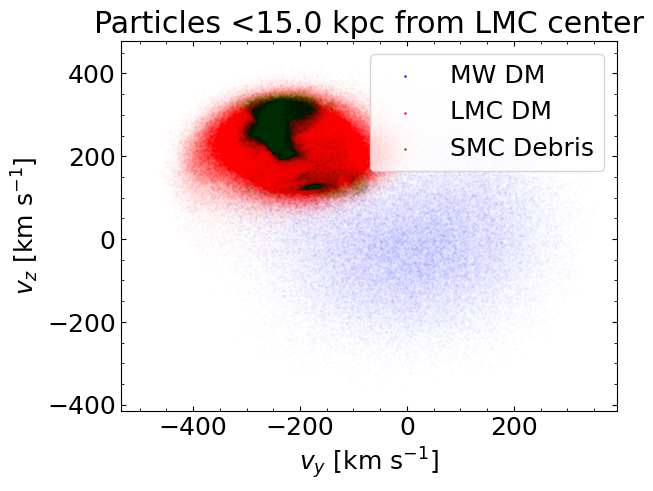

In [11]:
# vy-vz projection
fig, ax = plt.subplots()
ax.scatter(mw_dm.data_fields['Velocities'][:,1], mw_dm.data_fields['Velocities'][:,2], c='b', alpha=0.01, s=0.5, label='MW DM')
ax.scatter(lmc_dm.data_fields['Velocities'][:,1], lmc_dm.data_fields['Velocities'][:,2], c='r', alpha=0.01, s=0.5, label='LMC DM')
ax.scatter(smc_stars.data_fields['Velocities'][:,1], smc_stars.data_fields['Velocities'][:,2], c='g', alpha=0.01, s=0.5, label='SMC Debris')
ax.set(xlabel='$v_y$ [km s$^{-1}$]', ylabel='$v_z$ [km s$^{-1}$]', title=f"Particles <{r_max} kpc from LMC center")
leg = ax.legend(loc='upper right')
for lh in leg.legend_handles: 
    lh.set_alpha(1.0)

plt.savefig("lmc_mw_smc_velocities.png", bbox_inches='tight')
plt.show()